# 4. Auto-Labeling Pipeline

Discovers LiDAR tiles within the Amsterdam A10 ring, runs the full BGT/AHN labeling pipeline for each tile, then extracts DBSCAN obstacle clusters and auto-assigns labels from the BGT prior.

**Prerequisites:** Run `0.5. Data Setup.ipynb` first to ensure AHN and BGT base data are present.

**Output:**
- `CLUSTERS_DIR/<tilecode>/cluster_NNNN.npz` — per-cluster point arrays
- `CLUSTERS_DIR/inventory_<tilecode>.csv` — per-tile cluster metadata
- `CLUSTERS_DIR/inventory.csv` — aggregated inventory

**Pipeline order per tile:**
1. Download AHN tiles (if needed)
2. Process AHN → NPZ grids
3. Scrape BGT/Bomen data for tile extent
4. Ground + road fusion
5. BGT object labeling
6. Extract + save clusters

## Config

In [11]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path('.').resolve()))

from config import (
    TILE_DIR, AHN_RAW_DIR, AHN_NPZ_DIR, AHN_GRID_SHP,
    BGT_DIR, BOMEN_DIR, AFVAL_DIR, OSM_DIR, TERRAS_DIR,
    BBOX_DIR, LABELED_DIR, CLUSTERS_DIR, SETUP_TILECODES,
)

AUTO_LABEL_THRESH = 0.60   # dominant-label fraction for auto-assignment
REVIEW_THRESH     = 0.40

LABELED_DIR.mkdir(parents=True, exist_ok=True)
CLUSTERS_DIR.mkdir(parents=True, exist_ok=True)
BBOX_DIR.mkdir(parents=True, exist_ok=True)

## Step 1 — Resolve tile paths from SETUP_TILECODES

In [12]:
import numpy as np
import pandas as pd

TILECODES = SETUP_TILECODES
TILE_PATHS = {}

for tc in TILECODES:
    matches = list(TILE_DIR.rglob(f"{tc}.laz")) + list(TILE_DIR.rglob(f"{tc}.LAZ"))
    if matches:
        TILE_PATHS[tc] = str(matches[0])
    else:
        print(f"  [warn] {tc} — LAZ not found under {TILE_DIR}")

print(f"Tilecodes: {len(TILECODES)}  |  found: {len(TILE_PATHS)}")

  [warn] 121100_484900 — LAZ not found under /Users/minkeverweij/pc2025
  [warn] 121500_484900 — LAZ not found under /Users/minkeverweij/pc2025
  [warn] 121100_485300 — LAZ not found under /Users/minkeverweij/pc2025
  [warn] 121500_485300 — LAZ not found under /Users/minkeverweij/pc2025
Tilecodes: 9  |  found: 5


## Step 2 — Run preprocessing pipeline per tile

For each selected tile, runs (if not already done):
- AHN download + processing → NPZ grid
- BGT/Bomen data scraping  
- Ground + road fusion
- BGT object labeling

Tiles with an existing `bgt_labeled_<tilecode>.laz` are skipped.

In [13]:
import utils.labels as LabelsModule
from utils.ahn_reader import PolygonNPZReader
from utils.ahn_fuser import NPZAHNFuser
from utils.bgt_fuser import BGTRoadFuser
from utils.bgt_readers import BGTPointReader, get_bbox_from_polygon_file
from utils.bgt_poly_reader import BGTPolyReader
from utils.pole_fuser import BGTPoleFuser
from utils.street_furniture_fuser import BGTStreetFurnitureFuser
from utils.car_fuser import CarFuser
from utils.cable_fuser import CableFuser
import utils.pipeline as Pipeline
import geopandas as gpd
import json

Labels = LabelsModule.Labels

In [14]:
class CSVPointReader:
    """Tile-filtered reader for CSV files with x/y columns."""
    def __init__(self, csv_file, x_col='x', y_col='y', bbox_folder=None):
        self.df = pd.read_csv(csv_file)
        self.x_col = x_col
        self.y_col = y_col
        self.bbox_folder = Path(bbox_folder) if bbox_folder else None

    def _get_bbox(self, tilecode, padding):
        if self.bbox_folder is not None:
            return get_bbox_from_polygon_file(tilecode, self.bbox_folder, padding=padding)
        parts = tilecode.split('_')
        x_min = float(parts[0]) - padding
        y_min = float(parts[1]) - padding
        return ((x_min, y_min + 50 + 2*padding), (x_min + 50 + 2*padding, y_min))

    def filter_tile(self, tilecode, bgt_types=None, padding=0, return_types=False):
        ((bx_min, by_max), (bx_max, by_min)) = self._get_bbox(tilecode, padding)
        x, y = self.x_col, self.y_col
        df = self.df
        mask = (
            (df[x].astype(float) >= bx_min) & (df[x].astype(float) <= bx_max) &
            (df[y].astype(float) >= by_min) & (df[y].astype(float) <= by_max)
        )
        return [(float(row[x]), float(row[y])) for _, row in df[mask].iterrows()]

In [15]:
def build_ground_road_pipeline(tilecode):
    """Instantiate NPZAHNFuser + BGTRoadFuser for ground/road labeling.

    NOTE: this runs on the *raw* (non-downsampled) LAZ from TILE_DIR — for
    2025-vintage tiles (dense mobile-mapping clouds, up to ~30,000 pts/m²)
    that can exceed available memory. The cell below only calls this when
    `road_ground_labeled_<tilecode>.laz` doesn't already exist in
    LABELED_DIR, so running `2. Ground and Road fusion.ipynb` first (which
    downsamples before fusing) avoids the raw-cloud path here entirely. If
    you add a new tile without running notebook 2 first, this will hit the
    same memory risk notebook 2 was fixed for.
    """
    DOWNSAMPLE_VOXEL = 0.08   # keep in sync with notebook 2 and notebook 5
    MIN_COMP_SIZE = max(2, int((0.4 / DOWNSAMPLE_VOXEL) ** 2) - 1)

    npz_path = str(AHN_NPZ_DIR / f"ahn_{tilecode}.npz")

    ground_fuser = NPZAHNFuser(
        label=Labels.GROUND,
        npz_reader=npz_path,
        target='ground',
        epsilon=0.2,
        grid_size=0.4,
        min_comp_size=MIN_COMP_SIZE,
    )
    building_fuser = NPZAHNFuser(
        label=Labels.BUILDING,
        npz_reader=npz_path,
        target='building',
        epsilon=0.2,
        min_comp_size=MIN_COMP_SIZE,
    )

    BGT_LAYERS = [
        'BGT_WGL_rijbaan_lokale_weg', 'BGT_WGL_rijbaan_regionale_weg',
        'BGT_WGL_rijbaan_autoweg',    'BGT_WGL_rijbaan_autosnelweg',
        'BGT_WGL_parkeervlak',        'BGT_WGL_ov-baan',
        'BGT_WGL_fietspad',
    ]
    gdfs = []
    for layer in BGT_LAYERS:
        csv_path = BGT_DIR / f"{layer}.csv"
        if csv_path.exists():
            df = pd.read_csv(csv_path, sep=';')
            gdf = gpd.GeoDataFrame(
                df,
                geometry=gpd.GeoSeries.from_wkt(df['geometrie']),
                crs='EPSG:28992',
            )
            gdfs.append(gdf)
    bgt_gdf = pd.concat(gdfs, ignore_index=True) if gdfs else gpd.GeoDataFrame()

    road_fuser = BGTRoadFuser(
        label=Labels.ROAD,
        bgt_gdf=bgt_gdf,
        bgt_types=None,
        offset=0,
    )
    return Pipeline.Pipeline(
        processors=(ground_fuser, building_fuser, road_fuser),
        caching=False,
    )


def build_bgt_object_pipeline():
    """Instantiate all BGT object fusers (mirrors 2.5. BGT Object Labeling)."""
    ahn_reader = PolygonNPZReader(AHN_NPZ_DIR, caching=True)

    poles_reader     = BGTPointReader(bgt_file=str(BGT_DIR / "bgt_poles.csv"),           bbox_folder=str(BBOX_DIR))
    furniture_reader = BGTPointReader(bgt_file=str(BGT_DIR / "bgt_street_furniture.csv"), bbox_folder=str(BBOX_DIR))
    parking_reader   = BGTPolyReader(str(BGT_DIR / "bgt_parkeervakken.json"),             str(BBOX_DIR))

    bomen_reader     = CSVPointReader(str(BOMEN_DIR / "bomen_atlas.csv"),         'x', 'y', str(BBOX_DIR))
    oor_afval_reader = CSVPointReader(str(AFVAL_DIR / "afvalbakken_oor.csv"),      'x', 'y', str(BBOX_DIR))
    terras_reader    = CSVPointReader(str(TERRAS_DIR / "terrassen_centroids.csv"), 'x', 'y', str(BBOX_DIR))

    # osm_fiets_reader   = CSVPointReader(str(OSM_DIR / "osm_fietsparkeren.csv"),  'x', 'y', str(BBOX_DIR))
    # osm_parkeer_reader = CSVPointReader(str(OSM_DIR / "osm_parkeermeters.csv"),  'x', 'y', str(BBOX_DIR))
    # osm_reclame_reader = CSVPointReader(str(OSM_DIR / "osm_reclameborden.csv"),  'x', 'y', str(BBOX_DIR))

    return Pipeline.Pipeline(
        processors=(
            CarFuser(
                label=Labels.CAR, bgt_poly_reader=parking_reader, ahn_reader=ahn_reader,
                grid_size=0.1, min_component_size=100, overlap_perc=20,
                params={"min_height": 1.2, "max_height": 2.2,
                        "min_width": 1.4,  "max_width": 2.5,
                        "min_length": 2.5, "max_length": 6.0},
            ),
            BGTStreetFurnitureFuser(
                label=Labels.BICYCLE_RACK, bgt_type="fietsenrek",
                bgt_reader=furniture_reader, ahn_reader=ahn_reader, max_dist=1.5,
                params={"min_height": 0.5, "max_height": 1.4,
                        "min_width": 0.3, "max_width": 1.2,
                        "min_length": 1.0, "max_length": 5.0},
            ),
            # BGTStreetFurnitureFuser(
            #     label=Labels.BICYCLE_RACK, bgt_type="osm_fietsparkeren",
            #     bgt_reader=osm_fiets_reader, ahn_reader=ahn_reader, max_dist=1.5,
            #     params={"min_height": 0.5, "max_height": 1.4,
            #             "min_width": 0.3, "max_width": 1.2,
            #             "min_length": 1.0, "max_length": 5.0},
            # ),
            BGTStreetFurnitureFuser(
                label=Labels.LARGE_CONTAINER, bgt_type="afval apart plaats",
                bgt_reader=furniture_reader, ahn_reader=ahn_reader, max_dist=3.0,
                params={"min_height": 0.7, "max_height": 2.5,
                        "min_width": 0.4, "max_width": 2.5,
                        "min_length": 0.6, "max_length": 6.0},
            ),
            BGTStreetFurnitureFuser(
                label=Labels.CITY_BENCH, bgt_type="bank",
                bgt_reader=furniture_reader, ahn_reader=ahn_reader, max_dist=1.0,
                params={"min_height": 0.3, "max_height": 1.2,
                        "min_width": 0.3, "max_width": 0.9,
                        "min_length": 0.8, "max_length": 2.5},
            ),
            BGTStreetFurnitureFuser(
                label=Labels.RUBBISH_BIN, bgt_type="afvalbak",
                bgt_reader=oor_afval_reader, ahn_reader=ahn_reader,
                min_component_size=100, max_dist=1.0,
                params={"min_height": 0.4, "max_height": 1.2,
                        "min_width": 0.2, "max_width": 0.8,
                        "min_length": 0.2, "max_length": 0.8},
            ),
            BGTPoleFuser(
                label=Labels.STREET_LIGHT, bgt_type="lichtmast",
                bgt_reader=poles_reader, ahn_reader=ahn_reader,
                params={"search_pad": 1.5, "max_dist": 1.2,
                        "min_height": 2.0, "max_r": 0.3,
                        "r_mult": 1.5, "label_height": 5.0},
            ),
            BGTPoleFuser(
                label=Labels.TRAFFIC_LIGHT, bgt_type="verkeersregelinstallatiepaal",
                bgt_reader=poles_reader, ahn_reader=ahn_reader,
                params={"search_pad": 1.5, "max_dist": 1.2,
                        "min_height": 2.0, "max_r": 0.3,
                        "r_mult": 1.5, "label_height": 6.0},
            ),
            BGTPoleFuser(
                label=Labels.TRAFFIC_SIGN, bgt_type="verkeersbordpaal",
                bgt_reader=poles_reader, ahn_reader=ahn_reader,
                params={"search_pad": 1.5, "max_dist": 1.2,
                        "min_height": 2.0, "max_r": 0.25,
                        "r_mult": 1.5, "label_height": 4.0},
            ),
            # BGTPoleFuser(
            #     label=Labels.PARKING_METER, bgt_type="osm_parkeermeter",
            #     bgt_reader=osm_parkeer_reader, ahn_reader=ahn_reader,
            #     params={"search_pad": 1.0, "max_dist": 1.0,
            #             "min_height": 0.5, "max_r": 0.2,
            #             "r_mult": 1.5, "label_height": 1.5},
            # ),
            # BGTPoleFuser(
            #     label=Labels.ADVERTISING_SIGN, bgt_type="osm_reclamebord",
            #     bgt_reader=osm_reclame_reader, ahn_reader=ahn_reader,
            #     params={"search_pad": 1.5, "max_dist": 1.2,
            #             "min_height": 0.5, "max_r": 0.5,
            #             "r_mult": 1.5, "label_height": 3.0},
            # ),
            BGTStreetFurnitureFuser(
                label=Labels.TERRACE, bgt_type="terras",
                bgt_reader=terras_reader, ahn_reader=ahn_reader, max_dist=2.0,
                params={"min_height": 0.3, "max_height": 1.2,
                        "min_width": 0.5, "max_width": 8.0,
                        "min_length": 0.5, "max_length": 12.0},
            ),
            CableFuser(
                label=Labels.CABLE,
                cable_label=Labels.CABLE,
                tramcable_label=Labels.TRAM_CABLE,
                streetlight_label=Labels.ARMATUUR,
                ahn_reader=ahn_reader,
            ),
            BGTPoleFuser(
                label=Labels.TREE, bgt_type="boom",
                bgt_reader=bomen_reader, ahn_reader=ahn_reader,
                params={
                    "search_pad": 2.0, "max_dist": 1.5,
                    "min_height": 2.0, "max_r": 0.4,
                    "r_mult": 1.5, "label_height": 8.0,
                    "grow_crown": True,
                    "crown_r": 5.0, "crown_height": 25.0,
                    "crown_floor": 1.75,
                    "crown_grid_size": 0.25, "crown_min_comp": 20,
                    "crown_expand_step": 2.0, "crown_max_iter": 2,
                },
            ),
        ),
        caching=False,
    )

In [16]:
import traceback

bgt_pipeline = build_bgt_object_pipeline()

skipped, processed, failed = [], [], []

for tilecode in TILECODES:
    raw_laz   = TILE_PATHS[tilecode]
    gr_laz    = LABELED_DIR / f"road_ground_labeled_{tilecode}.laz"
    bgt_laz   = LABELED_DIR / f"bgt_labeled_{tilecode}.laz"

    if bgt_laz.exists():
        print(f"  [skip]  {tilecode} — bgt_labeled already exists")
        skipped.append(tilecode)
        continue

    print(f"\n  Processing {tilecode} …")
    try:
        # Ground + road fusion (requires AHN NPZ + BGT road CSVs)
        if not gr_laz.exists():
            gr_pipeline = build_ground_road_pipeline(tilecode)
            gr_pipeline.process_file(str(raw_laz), str(gr_laz))
            print(f"    Ground/road labeled: {gr_laz.name}")
        else:
            print(f"    Ground/road labeled: already exists")

        # BGT object labeling
        bgt_pipeline.process_file(str(gr_laz), str(bgt_laz))
        print(f"    BGT labeled: {bgt_laz.name}")
        processed.append(tilecode)

    except Exception:
        print(f"    ERROR on {tilecode}:")
        traceback.print_exc()
        failed.append(tilecode)

print(f"\nDone: {len(processed)} processed, {len(skipped)} skipped, {len(failed)} failed.")
if failed:
    print(f"Failed tilecodes: {failed}")

  [skip]  120300_489300 — bgt_labeled already exists
  [skip]  120300_488900 — bgt_labeled already exists
  [skip]  120700_489300 — bgt_labeled already exists
  [skip]  119900_489300 — bgt_labeled already exists
  [skip]  120300_489700 — bgt_labeled already exists


KeyError: '121100_484900'

## Step 3 — Extract obstacle clusters

Runs DBSCAN on unlabeled obstacle points and saves per-cluster NPZ files.

In [ ]:
from utils.cluster_io import extract_and_save_clusters, extract_bgt_objects, build_cluster_inventory

# DBSCAN neighbourhood radius for the generic (not-yet-BGT-matched) obstacle
# clusters below -- lowered from the 0.6m default to keep separate objects
# (e.g. a row of bikes vs. a nearby bench or tree trunk) from chain-merging
# into one oversized cluster. Tested on tile 120300_489300: 138 clusters at
# 0.3m vs. 47 at 0.6m, visibly more distinct boundaries. Lower further if
# clusters still contain multiple objects; raise if single objects start
# fragmenting into pieces.
CLUSTER_EPS = 0.3

# Step A: DBSCAN clusters of unknown + BGT-labeled obstacle points
cluster_results = []
for tilecode in TILECODES:
    bgt_laz = LABELED_DIR / f"bgt_labeled_{tilecode}.laz"
    if not bgt_laz.exists():
        print(f"  [skip]  {tilecode} — no bgt_labeled file found")
        continue
    print(f"\n── {tilecode} ──")
    inv = extract_and_save_clusters(
        laz_path=bgt_laz,
        out_dir=CLUSTERS_DIR,
        tilecode=tilecode,
        auto_label_thresh=AUTO_LABEL_THRESH,
        review_thresh=REVIEW_THRESH,
        eps=CLUSTER_EPS,
    )
    cluster_results.append(inv)

# Step B: per-object NPZs from BGT-labeled points (trees + street lights by default).
# Each label class is clustered in isolation — a bike next to a tree (label 0/44)
# is never in the tree point set (label 30), so no cross-object merging can occur.
print("\n── BGT object extraction ──")
for tilecode in TILECODES:
    bgt_laz = LABELED_DIR / f"bgt_labeled_{tilecode}.laz"
    if not bgt_laz.exists():
        continue
    bgt_inv = extract_bgt_objects(
        laz_path=bgt_laz,
        out_dir=CLUSTERS_DIR,
        tilecode=tilecode,
        # label_classes=[Labels.TREE, Labels.STREET_LIGHT]  # default
    )
    cluster_results.append(bgt_inv)

print("\nBuilding aggregated inventory …")
inventory = build_cluster_inventory(CLUSTERS_DIR)
print(f"Total clusters: {len(inventory)}")
print(inventory.groupby('label')['cluster_idx'].count().rename('count').to_string())
inventory.to_csv(CLUSTERS_DIR / "inventory.csv", index=False)
print(f"Saved: {CLUSTERS_DIR / 'inventory.csv'}")

## Step 4 — Summary

In [18]:
import utils.labels as LabelsModule

print("=" * 60)
print(f"Tiles processed:       {len(TILECODES)}")
print(f"Total clusters:        {len(inventory)}")

auto   = inventory[inventory['label'] != 0]
unknwn = inventory[inventory['label'] == 0]
review = inventory[inventory['needs_review'] == True]

print(f"Auto-labeled:          {len(auto)} ({100*len(auto)/max(len(inventory),1):.0f}%)")
print(f"Needs manual review:   {len(review)}")
print(f"Fully unknown:         {len(unknwn)}")
print()
print("Auto-label distribution:")
for label_code, count in inventory['label'].value_counts().items():
    name = LabelsModule.Labels.STR_DICT.get(int(label_code), str(label_code))
    bar = '█' * (count * 40 // max(1, inventory['label'].value_counts().iloc[0]))
    print(f"  {name:<22} (code {int(label_code):>3}):  {count:>6}  {bar}")

Tiles processed:       9
Total clusters:        329
Auto-labeled:          73 (22%)
Needs manual review:   257
Fully unknown:         256

Auto-label distribution:
  Unknown                (code   0):     256  ████████████████████████████████████████
  Tree                   (code  30):      37  █████
  Streetlight            (code  60):      27  ████
  Car                    (code  40):       8  █
  Large container        (code  83):       1  


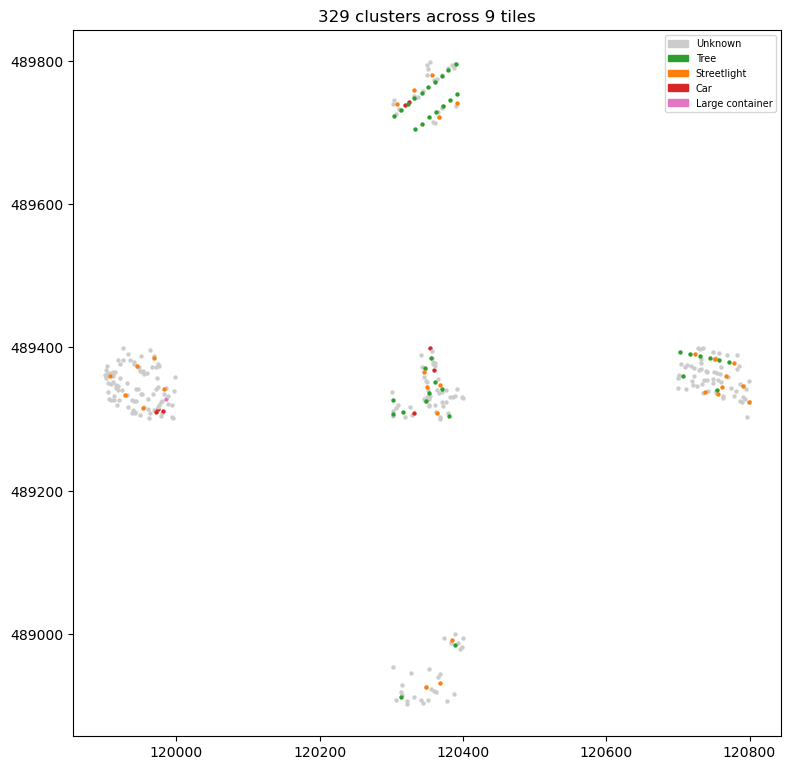

In [19]:
# Map: cluster centroids coloured by auto-label
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

LABEL_COLORS = {
     0: '#cccccc', 30: '#2ca02c', 40: '#d62728', 60: '#ff7f0e',
    80: '#9467bd', 81: '#8c564b', 83: '#e377c2', 44: '#1f77b4',
    46: '#17becf', 47: '#aec7e8', 45: '#bcbd22', 65: '#7f7f7f', 99: '#eeeeee',
}

fig, ax = plt.subplots(figsize=(8, 8))
handles = {}
for _, row in inventory.iterrows():
    lbl = int(row['label'])
    col = LABEL_COLORS.get(lbl, '#888888')
    ax.scatter(row['centroid_x'], row['centroid_y'], c=col, s=10, linewidths=0)
    if lbl not in handles:
        name = LabelsModule.Labels.STR_DICT.get(lbl, str(lbl))
        handles[lbl] = mpatches.Patch(color=col, label=name)

ax.legend(handles=list(handles.values()), fontsize=7, loc='upper right')
ax.set_aspect('equal')
ax.set_title(f"{len(inventory)} clusters across {len(TILECODES)} tiles")
plt.tight_layout()
plt.show()

## Step 5 — Per-tile cluster map with BGT objects

/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_14381/1687960006.py:93: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sel[:, 0], sel[:, 1], marker=marker, c=color,


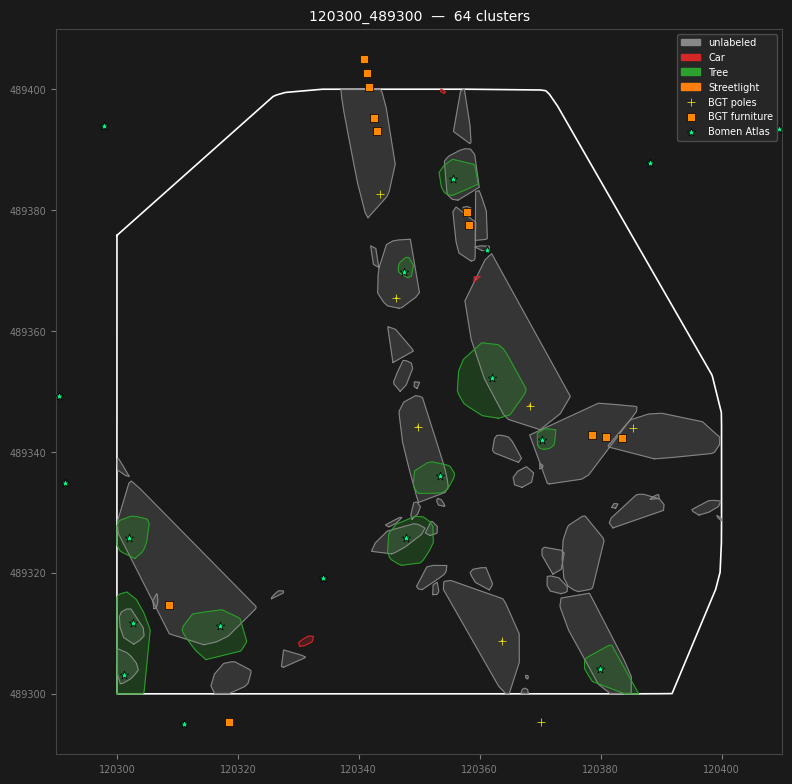

/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_14381/1687960006.py:93: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sel[:, 0], sel[:, 1], marker=marker, c=color,


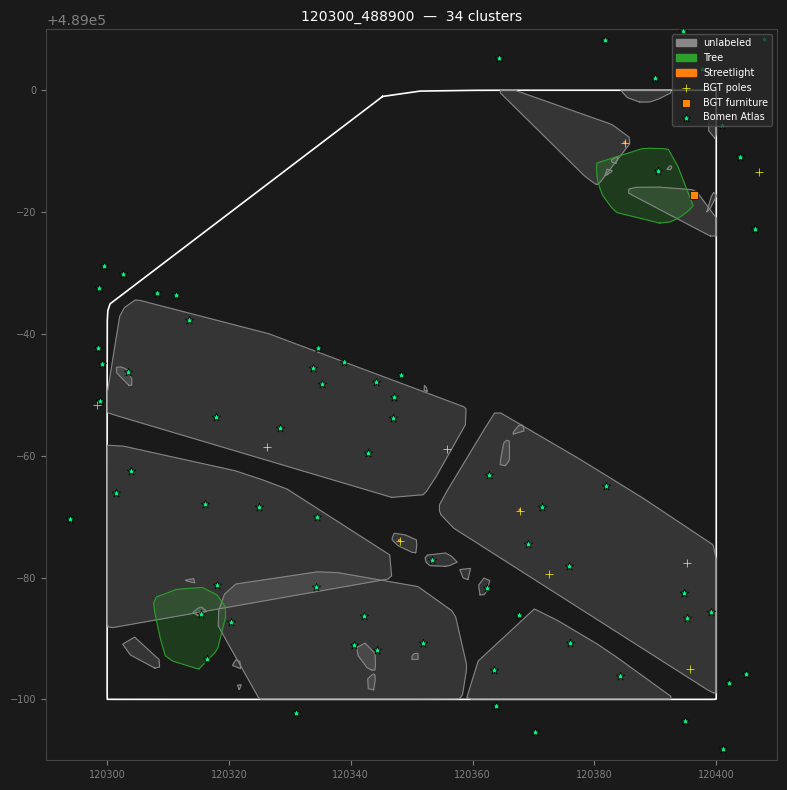

/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_14381/1687960006.py:93: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sel[:, 0], sel[:, 1], marker=marker, c=color,


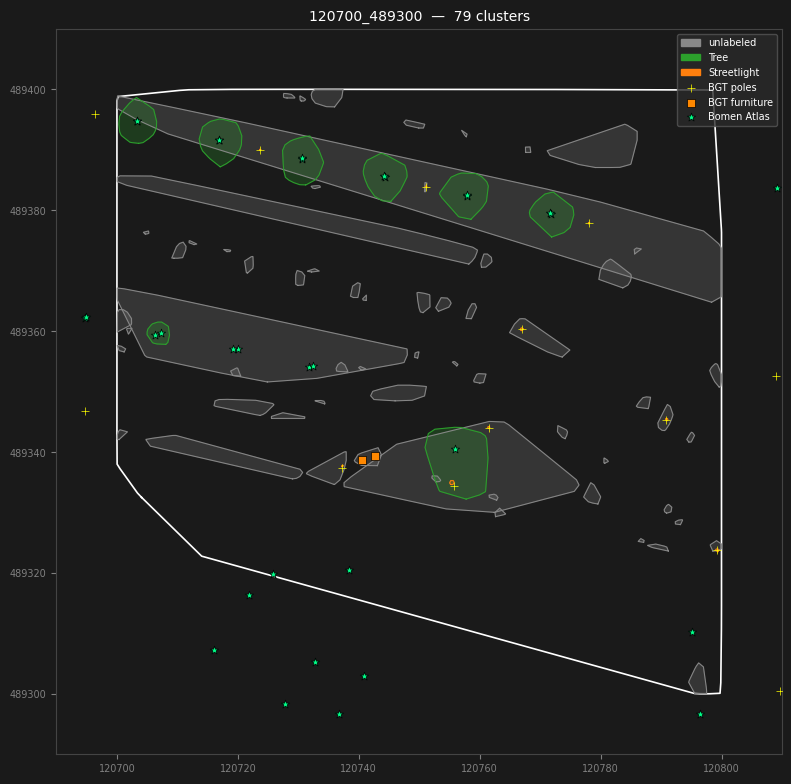

/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_14381/1687960006.py:93: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sel[:, 0], sel[:, 1], marker=marker, c=color,


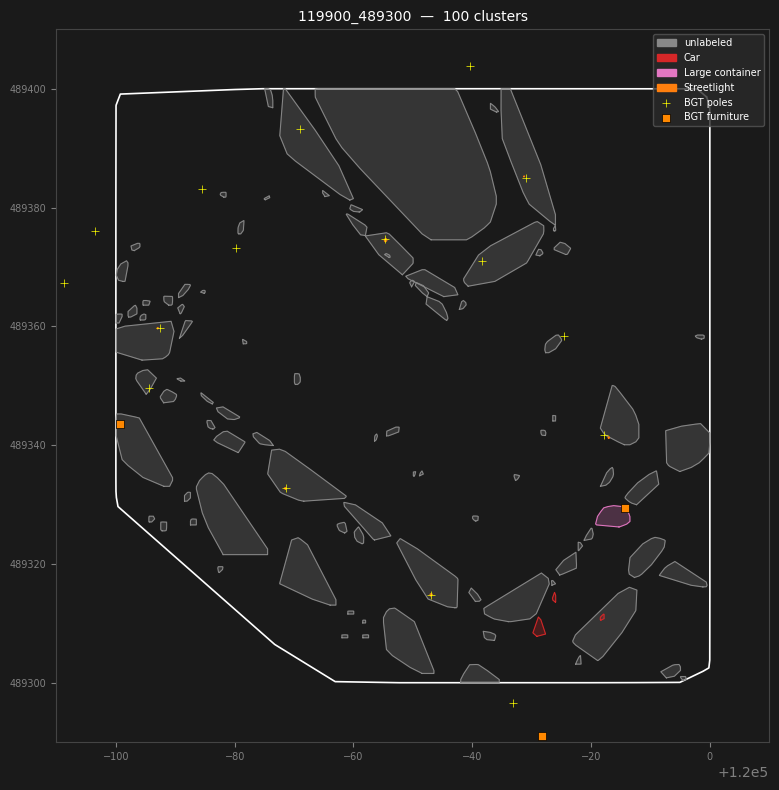

/var/folders/xm/kv_h3z3j6113q49b_8lb9xdh0000gn/T/ipykernel_14381/1687960006.py:93: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(sel[:, 0], sel[:, 1], marker=marker, c=color,


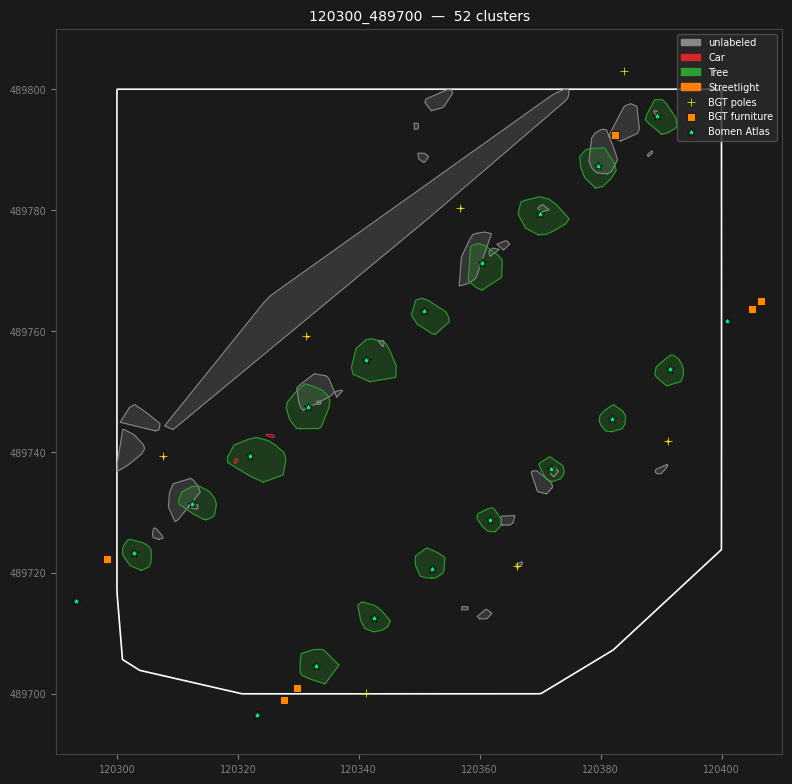

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import json
import numpy as np
import pandas as pd
from pathlib import Path
from shapely.geometry import shape

LABEL_COLORS = {
     0: '#888888', 30: '#2ca02c', 40: '#d62728', 44: '#1f77b4',
    46: '#17becf', 47: '#aec7e8', 45: '#bcbd22', 60: '#ff7f0e',
    65: '#7f7f7f', 80: '#9467bd', 81: '#8c564b', 83: '#e377c2',
    99: '#444444',
}

# Load BGT point objects once
def _load_csv_pts(path):
    if not Path(path).exists():
        return np.empty((0, 2))
    df = pd.read_csv(path)
    return df[['x', 'y']].values if {'x', 'y'}.issubset(df.columns) else np.empty((0, 2))

bgt_poles_pts  = _load_csv_pts(BGT_DIR / "bgt_poles.csv")
bgt_furn_pts   = _load_csv_pts(BGT_DIR / "bgt_street_furniture.csv")
bomen_pts      = _load_csv_pts(BOMEN_DIR / "bomen_atlas.csv")

for tc in TILECODES:
    tile_inv = inventory[inventory['tilecode'] == tc]
    if len(tile_inv) == 0:
        continue

    # Tile bounding box
    bbox_path = BBOX_DIR / f"bbox_{tc}.geojson"
    if not bbox_path.exists():
        continue
    with open(bbox_path) as f:
        bbox_gj = json.load(f)
    tile_poly = shape(bbox_gj['features'][0]['geometry'])
    bx0, by0, bx1, by1 = tile_poly.bounds
    pad = 10

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_facecolor('#1a1a1a')
    fig.patch.set_facecolor('#1a1a1a')

    # Tile outline
    tx, ty = tile_poly.exterior.xy
    ax.plot(tx, ty, 'w-', linewidth=1.2, zorder=2)

    # Cluster hulls coloured by label
    cluster_dir = CLUSTERS_DIR / tc
    legend_labels = {}
    for _, row in tile_inv.iterrows():
        npz_path = row['npz_path']
        if not Path(npz_path).exists():
            continue
        data = np.load(npz_path, allow_pickle=False)
        cx, cy = float(data['centroid_xy'][0]), float(data['centroid_xy'][1])
        xyz_c = data['xyz_centered'].astype(np.float32)
        pts2d = xyz_c[:, :2] + np.array([cx, cy], dtype=np.float32)

        lbl = int(row['label'])
        col = LABEL_COLORS.get(lbl, '#888888')
        name = LabelsModule.Labels.STR_DICT.get(lbl, 'unknown') if lbl != 0 else 'unlabeled'

        # Convex hull outline
        from shapely.geometry import MultiPoint
        hull = MultiPoint(pts2d.astype(np.float64)).convex_hull
        if hull.geom_type == 'Polygon':
            hx, hy = hull.exterior.xy
            ax.fill(hx, hy, color=col, alpha=0.25, zorder=3)
            ax.plot(hx, hy, color=col, linewidth=0.7, zorder=4)
        else:
            ax.scatter(pts2d[:, 0], pts2d[:, 1], c=col, s=4, linewidths=0, zorder=3)

        if name not in legend_labels:
            legend_labels[name] = col

    # BGT poles in tile area
    in_tile = lambda pts: (pts[:, 0] >= bx0-pad) & (pts[:, 0] <= bx1+pad) & \
                          (pts[:, 1] >= by0-pad) & (pts[:, 1] <= by1+pad)

    for pts, marker, color, label in [
        (bgt_poles_pts, '+',  '#ffff00', 'BGT poles'),
        (bgt_furn_pts,  's',  '#ff8800', 'BGT furniture'),
        (bomen_pts,     '*',  '#00ff88', 'Bomen Atlas'),
    ]:
        if len(pts) == 0:
            continue
        sel = pts[in_tile(pts)]
        if len(sel):
            ax.scatter(sel[:, 0], sel[:, 1], marker=marker, c=color,
                       s=40, linewidths=0.5, edgecolors='black',
                       zorder=5, label=label)

    ax.set_xlim(bx0 - pad, bx1 + pad)
    ax.set_ylim(by0 - pad, by1 + pad)
    ax.set_aspect('equal')
    ax.set_title(f'{tc}  —  {len(tile_inv)} clusters', color='white', fontsize=10)
    ax.tick_params(colors='grey', labelsize=7)
    for sp in ax.spines.values():
        sp.set_edgecolor('#444')

    cluster_patches = [mpatches.Patch(color=c, label=n) for n, c in legend_labels.items()]
    handles, labels_ = ax.get_legend_handles_labels()
    ax.legend(handles=cluster_patches + handles,
              labels=list(legend_labels.keys()) + labels_,
              fontsize=7, facecolor='#2a2a2a', edgecolor='#555',
              labelcolor='white', loc='upper right')

    plt.tight_layout()
    plt.show()